final text_encoder_type: bert-base-uncased


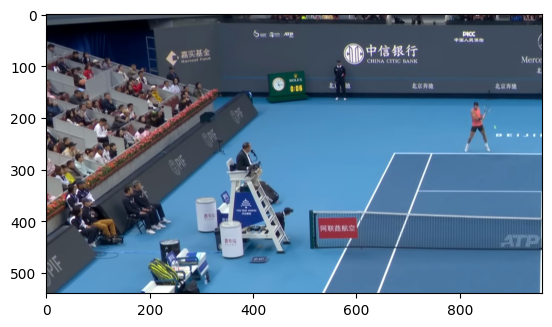

In [24]:
from groundingdino.util.inference import load_model, load_image, predict, annotate, batch_predict
import cv2
import torch
import matplotlib.pyplot as plt
from PIL import Image

model = load_model("groundingdino/config/GroundingDINO_SwinT_OGC.py", "groundingdino_swint_ogc.pth")
IMAGE_PATH = "/Users/derek/Desktop/tennis_tracker/tennis_tracker/download_data/frames/Jannik Sinner vs Carlos Alcaraz For The Title! 🏆 ｜ Beijing 2024 Final Highlights [Kv_obyZNKl4]/101.png"
IMAGE_PATH = "top_l.png"
TEXT_PROMPT = "blurry tennis ball"
BOX_TRESHOLD = 0.35
TEXT_TRESHOLD = 0.25

img = Image.open(IMAGE_PATH)
image_source, image = load_image(IMAGE_PATH)
plt.imshow(img)


In [25]:
images = torch.stack([image, image])
boxes, logits, boxes_to_im = batch_predict(
    model=model,
    preprocessed_images=images,
    caption=TEXT_PROMPT,
    box_threshold=BOX_TRESHOLD,
    text_threshold=TEXT_TRESHOLD,
    device="cpu"
)

annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=["object"])
cv2.imwrite("annotated_image.jpg", annotated_frame)

SupervisionWarnings: annotate is deprecated: `BoxAnnotator` is deprecated and will be removed in `supervision-0.22.0`. Use `BoundingBoxAnnotator` and `LabelAnnotator` instead


True

In [26]:
logits

tensor([0.5493, 0.3706, 0.5493, 0.3706])

In [10]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np

img = Image.open("annotated_image.jpg")
img = np.array(img)
h, w, _ = img.shape
top_l = Image.fromarray(img[:int(h/2), :int(w/2)])
top_r = Image.fromarray(img[:int(h/2), int(w/2):])
bottom_l = Image.fromarray(img[int(h/2):, :int(w/2)])
bottom_r = Image.fromarray(img[int(h/2):, int(w/2):])

top_l.save("top_l.png")
top_r.save("top_r.png")
bottom_l.save("bottom_l.png")
bottom_r.save("bottom_r.png")